<a href="https://colab.research.google.com/github/ERAEstudianteUB2026/UBPhD-Machine-Learning2026/blob/main/Taller3MLS3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller 3 Semana 3 ML**

## Autor:**Emiliano Rodríguez Arango**

## **Fecha:15/09/2026**

## Cargar librerias

In [ ]:
# Cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar datos

In [ ]:
url ="https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv"
df = pd.read_csv(url)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Información de las variables

| # | Variable | Non-Null Count | Tipo de dato |
|---|---|---:|---|
| 0 | **longitude** | 20640 non-null | float64 |
| 1 | **latitude** | 20640 non-null | float64 |
| 2 | **housing_median_age** | 20640 non-null | float64 |
| 3 | **total_rooms** | 20640 non-null | float64 |
| 4 | **total_bedrooms** | 20433 non-null | float64 |
| 5 | **population** | 20640 non-null | float64 |
| 6 | **households** | 20640 non-null | float64 |
| 7 | **median_income** | 20640 non-null | float64 |
| 8 | **median_house_value** | 20640 non-null | float64 |
| 9 | **ocean_proximity** | 20640 non-null | object |

In [ ]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


## Exploración de la data

In [ ]:
#Mirar datos faltantes.
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


El conjunto de datos presenta **207 valores faltantes**, todos concentrados en la variable `total_bedrooms`.

# Estadísticas descritivas




In [ ]:
#Hacemos copias de los datos
df_descriptivas=df.copy()

In [ ]:
#Ahora saamos la varibales de latitud y longitud
df_descriptivas=df_descriptivas.drop(['latitude','longitude', 'ocean_proximity'],axis=1)

In [ ]:

def descriptivas(df):
  resultados=[]
  for i in df.columns:
    media=df[i].mean()
    mediana=df[i].median()
    desviacion_estandar=df[i].std()
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    minimo=df[i].min()
    maximo=df[i].max()
    cv=(df[i].std()/df[i].mean())*100
    resultados.append({
        'variable':i,
        'media':media,
        'mediana':mediana,
        'desviacion_estandar':desviacion_estandar,
        'q1':q1,
        'q3':q3,
        'iqr':iqr,
        'minimo':minimo,
        'maximo':maximo,
        'cv':cv
    })
  resultados= pd.DataFrame(resultados)
  return resultados.round(2)



In [ ]:
#Usamos nuestra funcion de esatdirias desciptivas
descriptivas(df_descriptivas)

,variable,media,mediana,desviacion_estandar,q1,q3,iqr,minimo,maximo,cv
0,housing_median_age,28.64,29.00,12.59,18.00,37.00,19.00,1.0,52.0,43.94
1,total_rooms,2635.76,2127.00,2181.62,1447.75,3148.00,1700.25,2.0,39320.0,82.77
2,total_bedrooms,537.87,435.00,421.39,296.00,647.00,351.00,1.0,6445.0,78.34
3,population,1425.48,1166.00,1132.46,787.00,1725.00,938.00,3.0,35682.0,79.44
4,households,499.54,409.00,382.33,280.00,605.00,325.00,1.0,6082.0,76.54
5,median_income,3.87,3.53,1.90,2.56,4.74,2.18,0.5,15.0,49.08
6,median_house_value,206855.82,179700.00,115395.62,119600.00,264725.00,145125.00,14999.0,500001.0,55.79


Temos que las varibales cuantitativa incluida la de repsuesta presentan alta varibilidad, todas tiene un cv>>20%

# Gráficas de las variables cuantitativas.

In [ ]:
def graficas(df):
  for i in df.columns:
    plt.figure(figsize=(10, 8))
    plt.hist(df[i], bins=20, edgecolor='black')
    plt
    plt.xlabel(i)
    plt.ylabel('Frecuencia')
    plt.title(f'Histograma de {i}')
    plt.show()
    #siguiente
    plt.figure(figsize=(10, 8))
    sns.boxplot(x=df[i])
    plt.xlabel(i)
    plt.ylabel('Frecuencia')
    plt.title(f'Boxplot de {i}')
    plt.show
    #ahora finalizamos
    plt.figure(figsize=(10, 8))
  return plt.show()



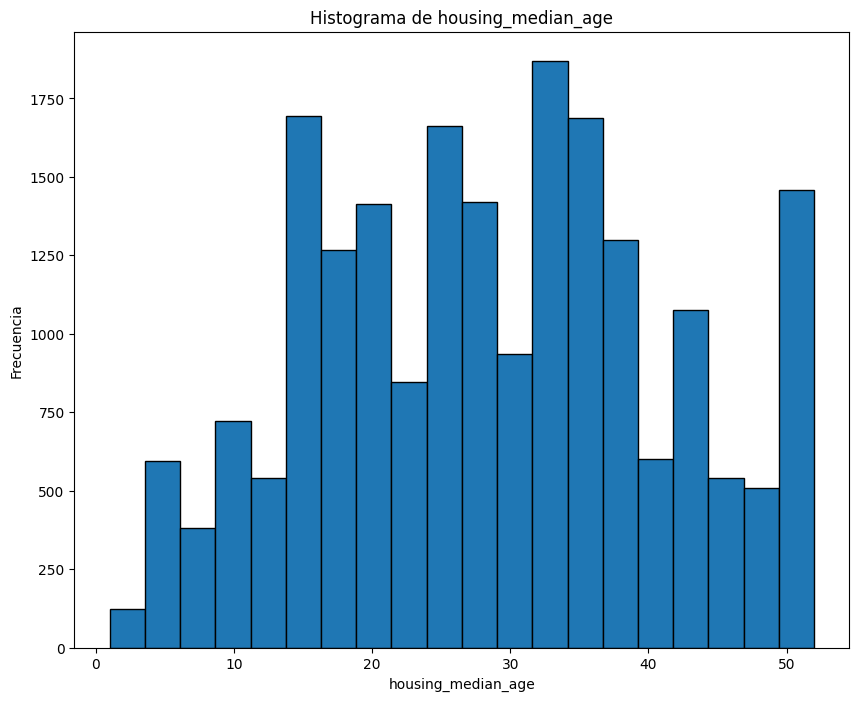

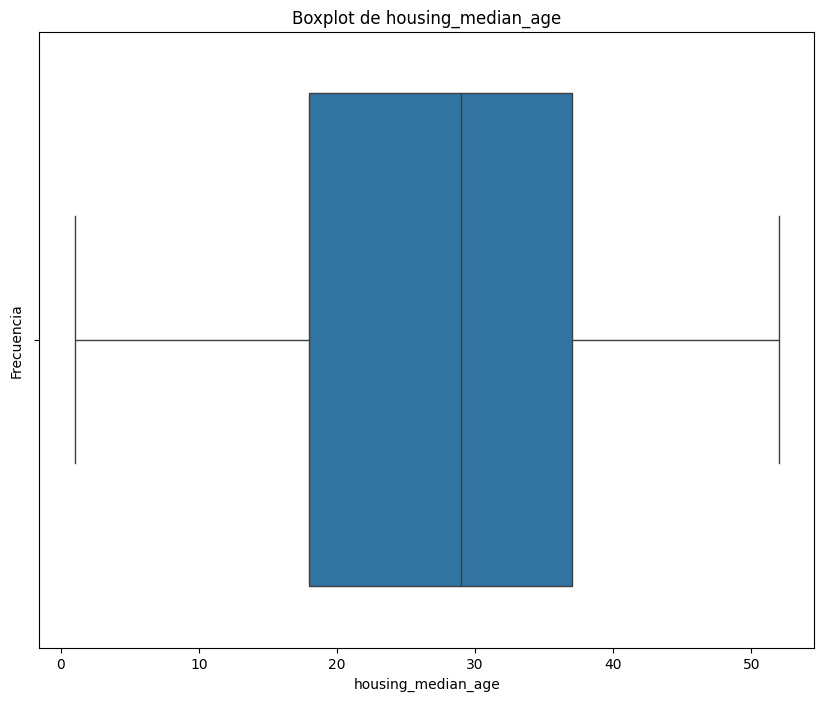

<Figure size 1000x800 with 0 Axes>

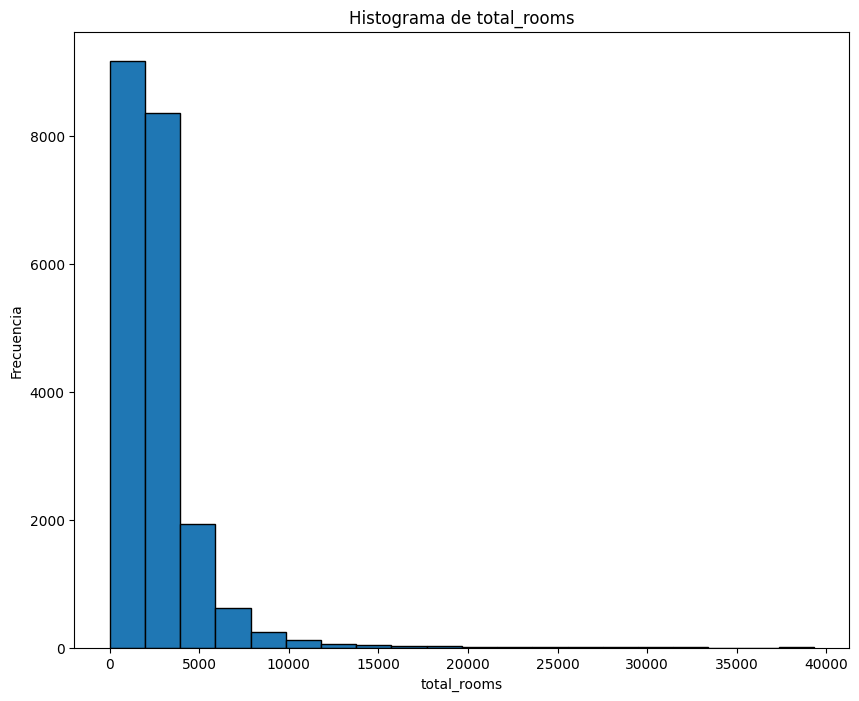

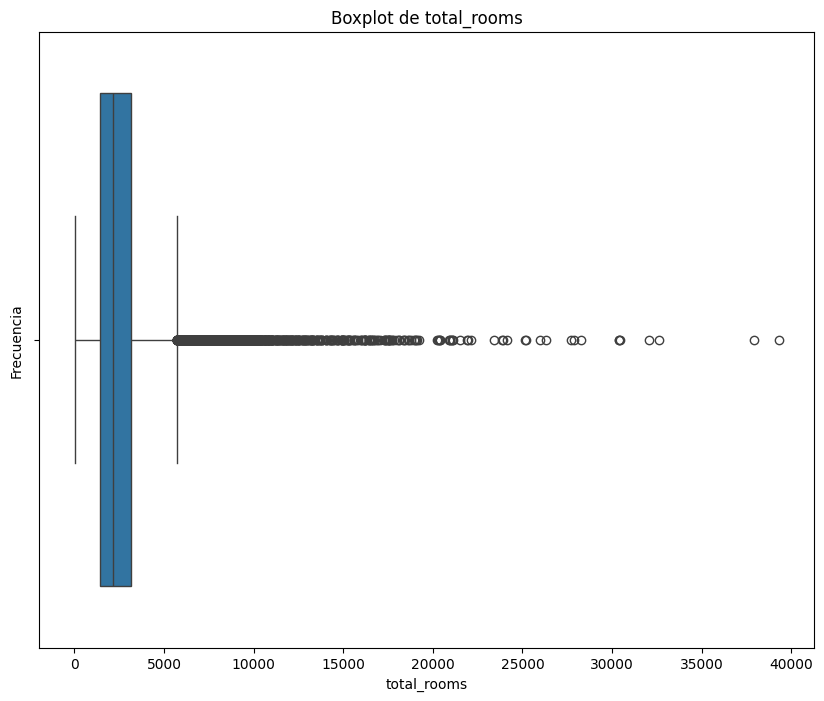

<Figure size 1000x800 with 0 Axes>

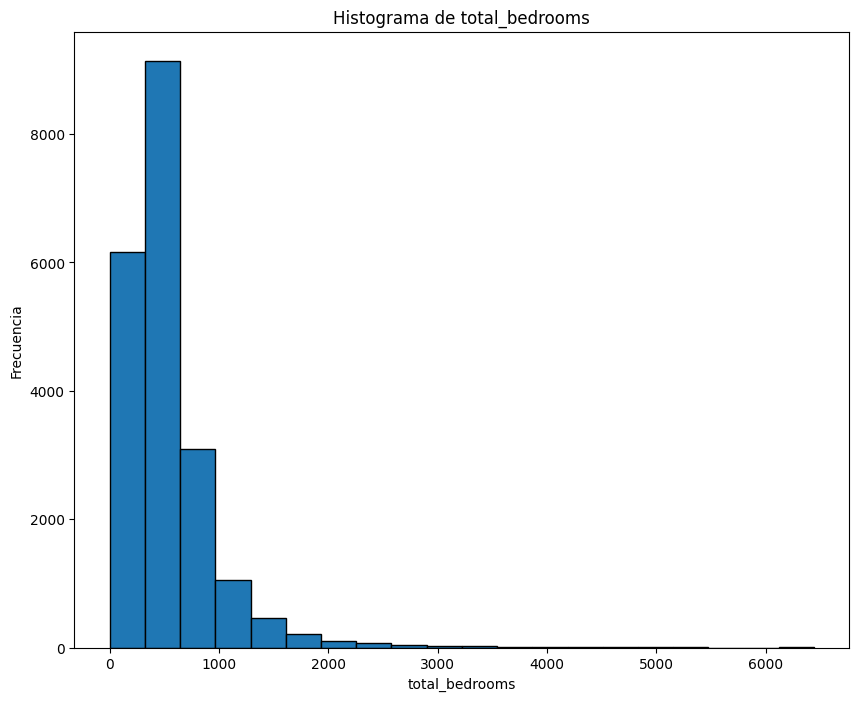

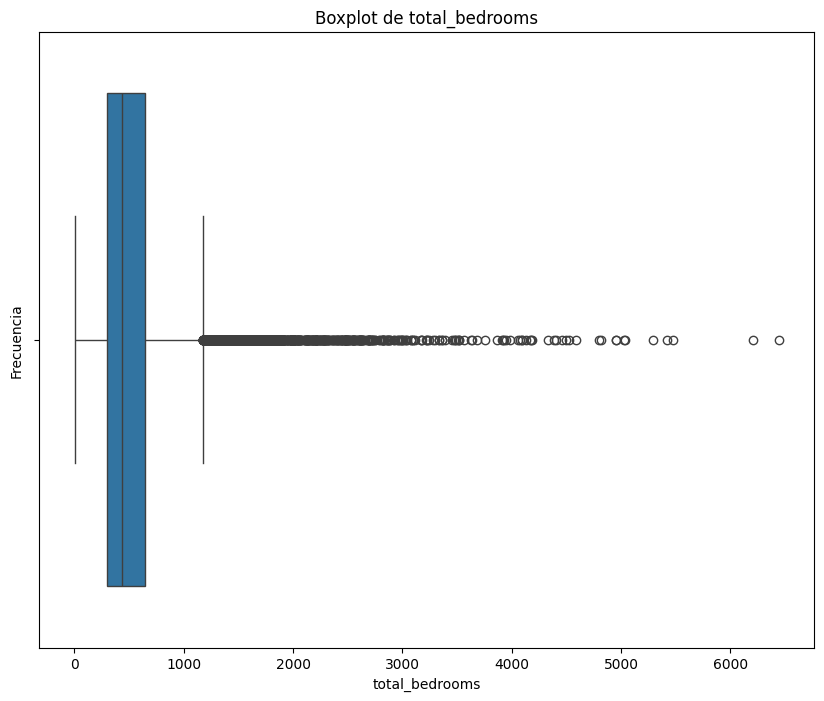

<Figure size 1000x800 with 0 Axes>

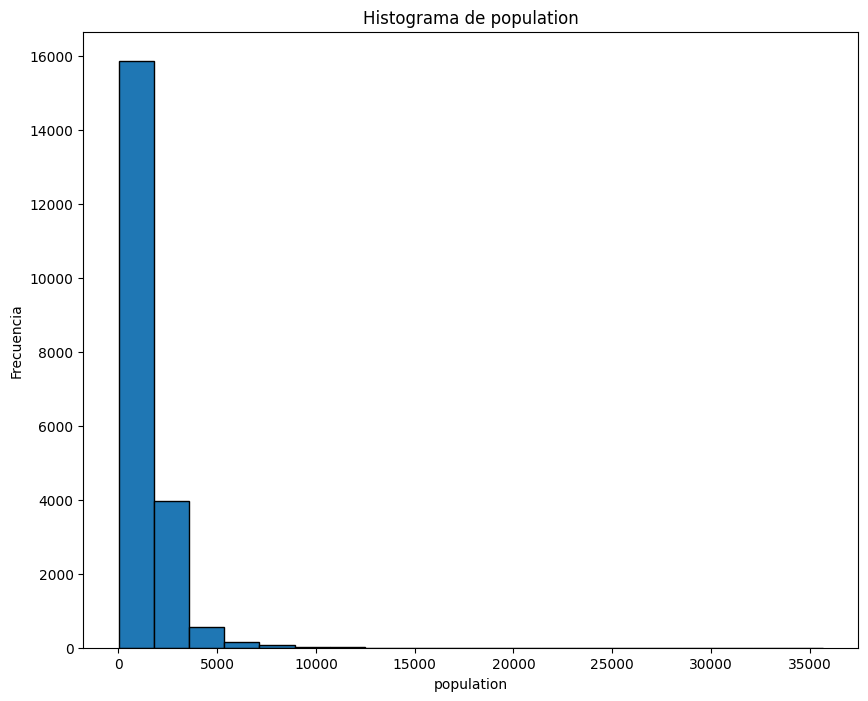

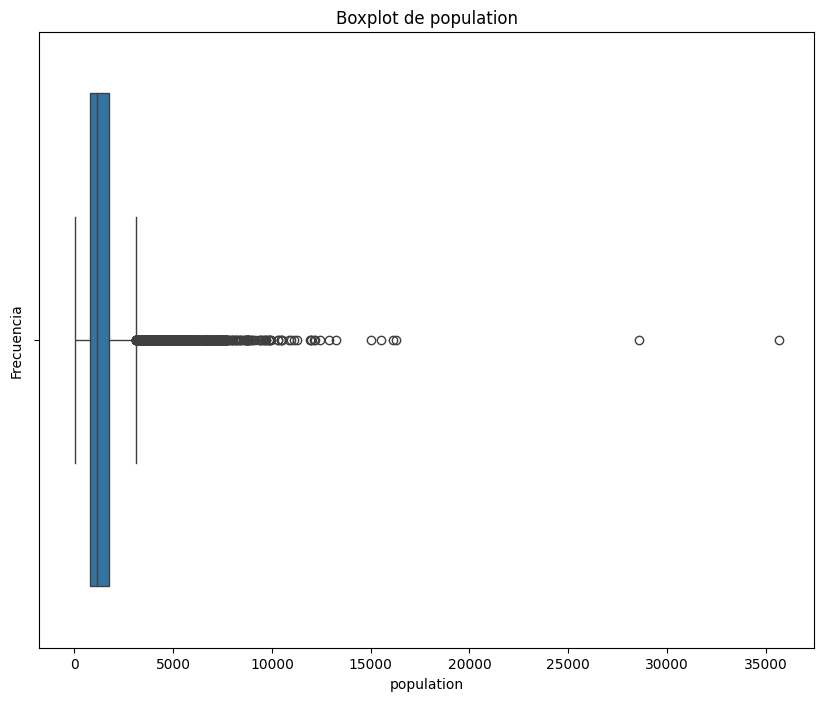

<Figure size 1000x800 with 0 Axes>

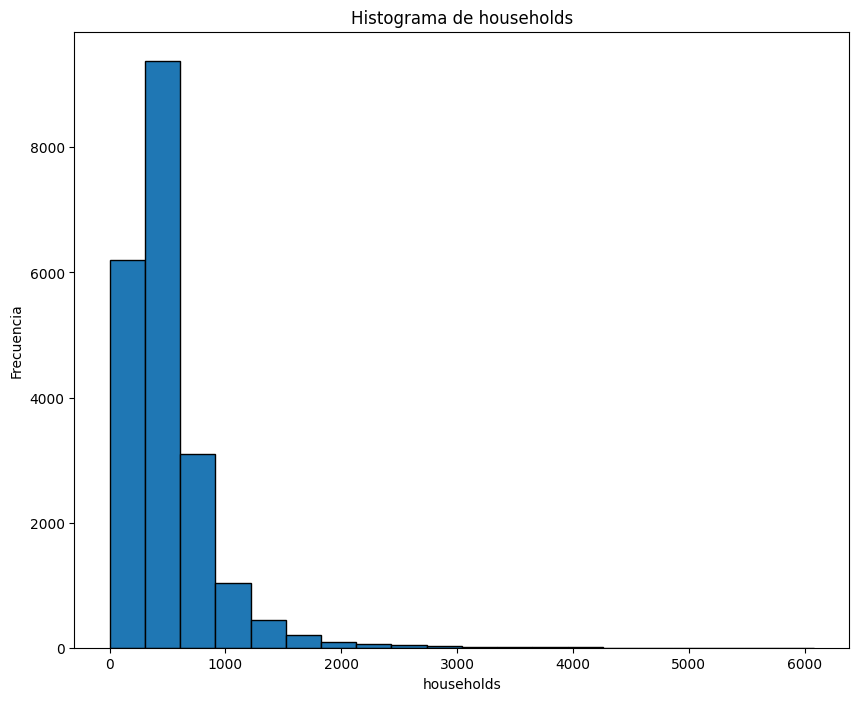

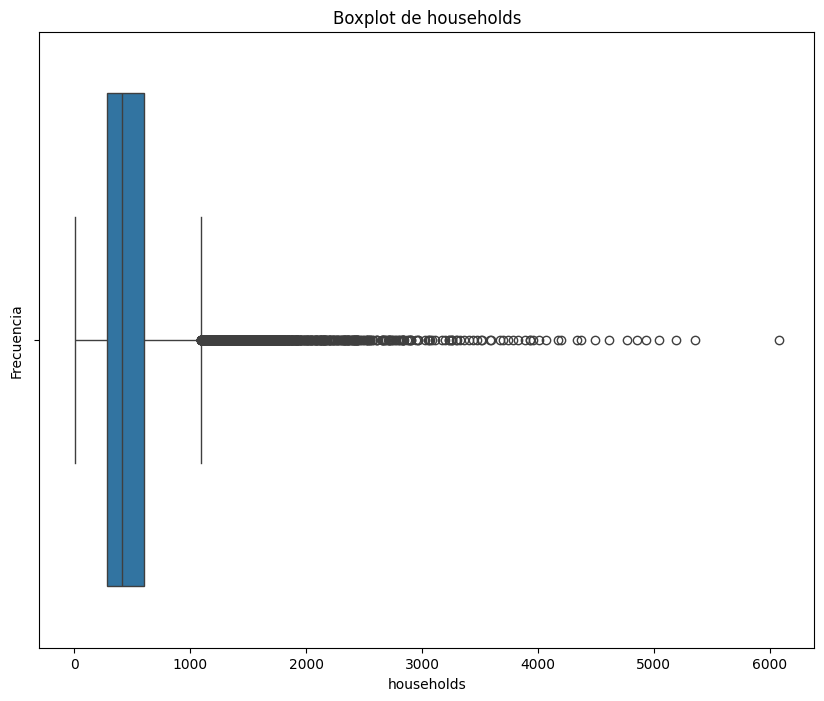

<Figure size 1000x800 with 0 Axes>

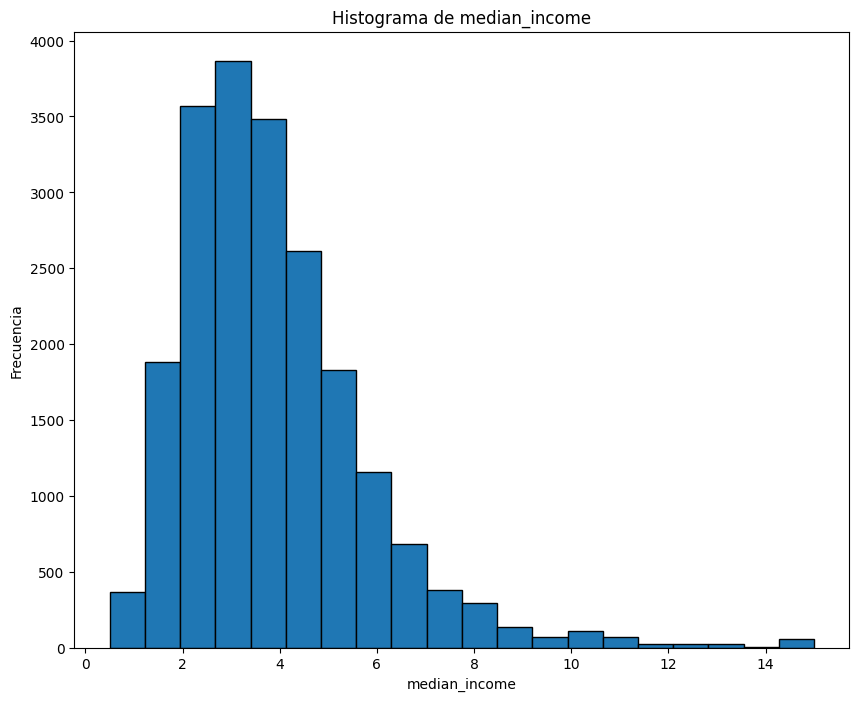

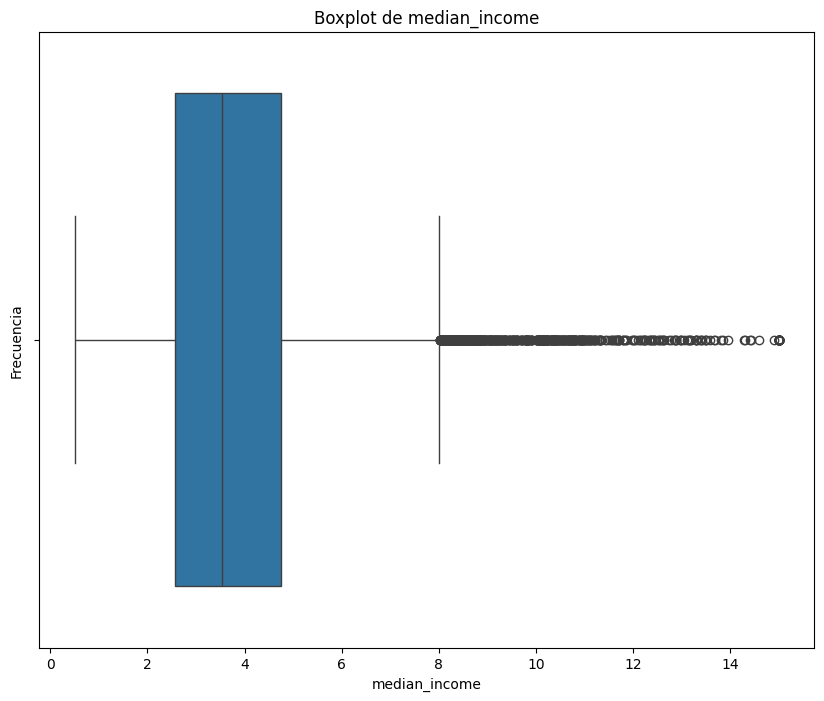

<Figure size 1000x800 with 0 Axes>

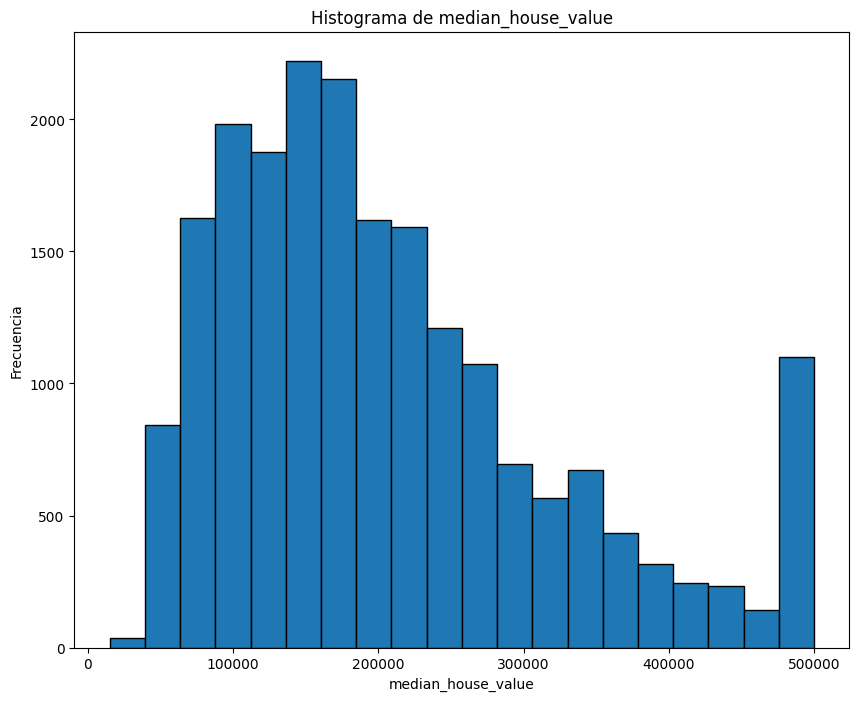

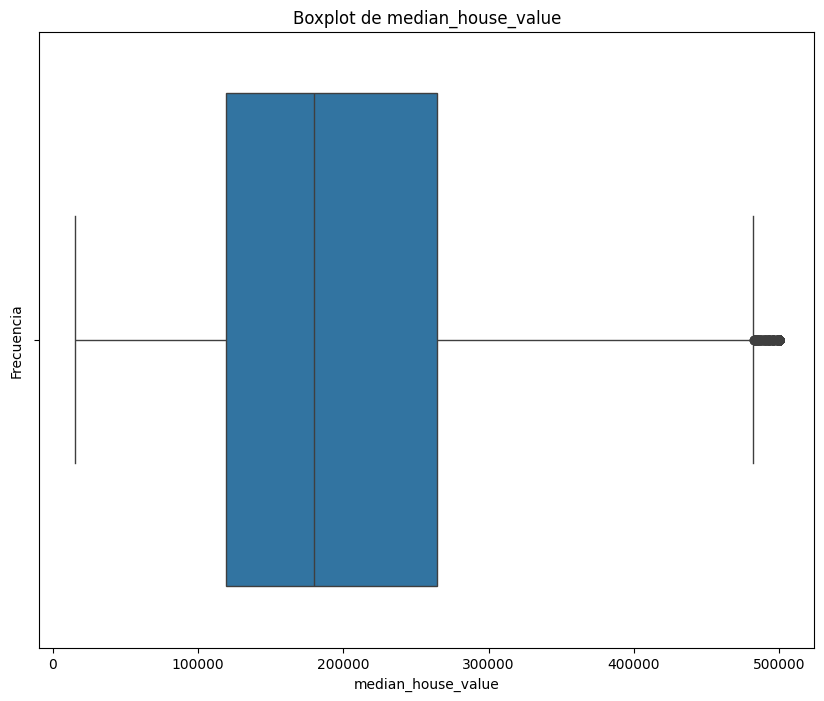

<Figure size 1000x800 with 0 Axes>

In [ ]:
graficas(df_descriptivas)

Se puede ver que muchas variables tiene muchos valores atípico  y además asimetría positiva

## Matriz de correlacipón



<Axes: >

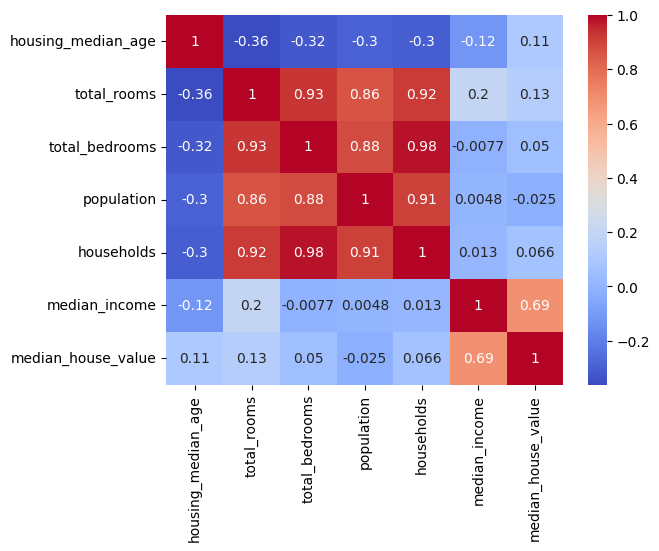

In [ ]:
#ahor hademos la matriz de correlación
corr=df_descriptivas.corr()
import seaborn as sns
#importar de sns el heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')

Podemos ver la correlación lineal de la respuesta con el resto de variables cuantativas no es fuerte.

## Grafios de dispersión de median_house_value vs las demás variables cuantis

In [ ]:
def graficas_dispersion(df):
  for i in df.columns:
    if i != 'median_house_value':
      plt.figure(figsize=(10, 8))
      plt.scatter(df[i], df['median_house_value'])
      plt.xlabel(i)
      plt.ylabel('median_house_value')
      plt.show()
    else:
      print(f"La variable {i} es la variable objetivo")


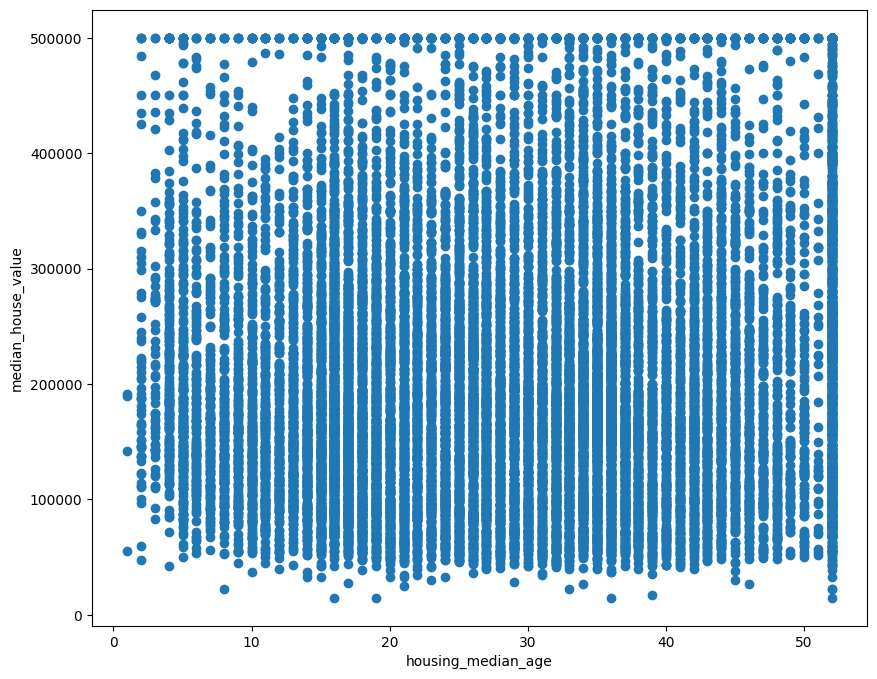

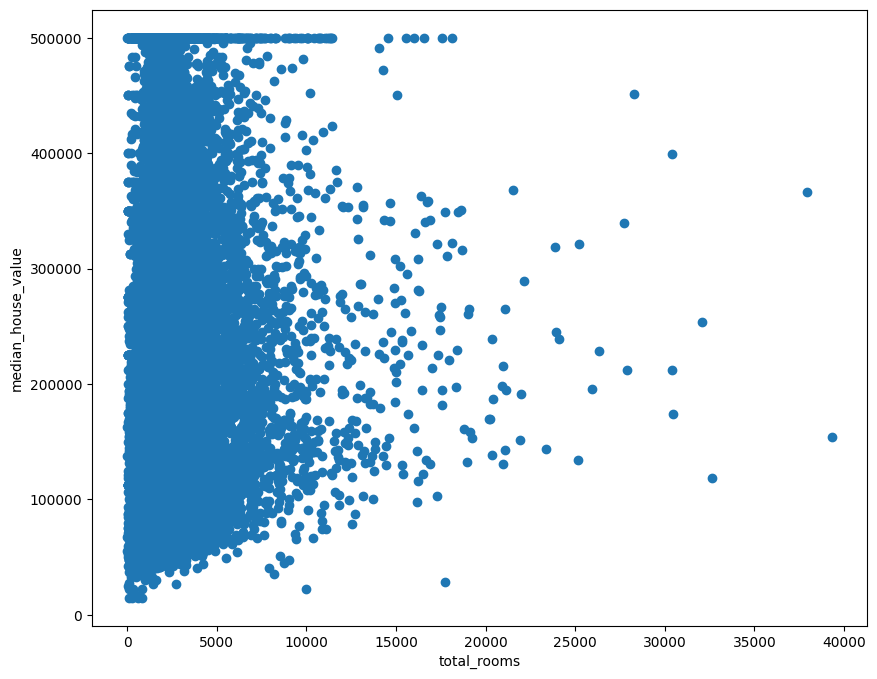

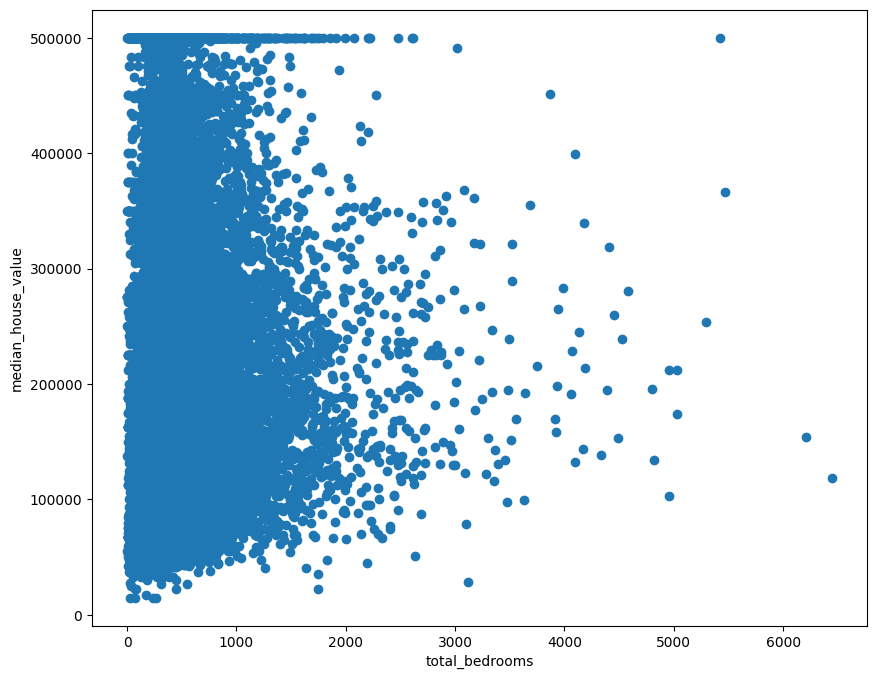

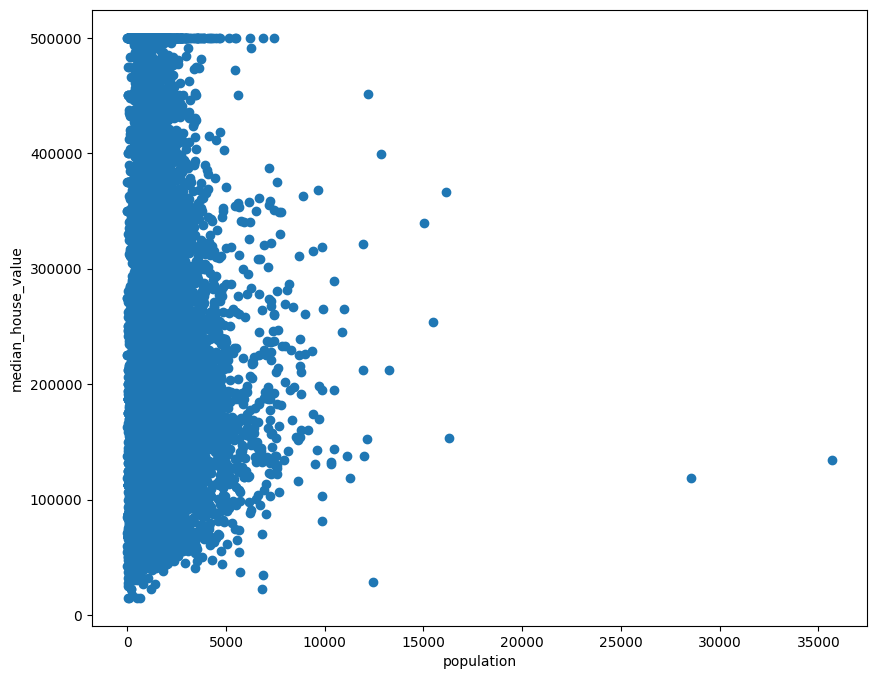

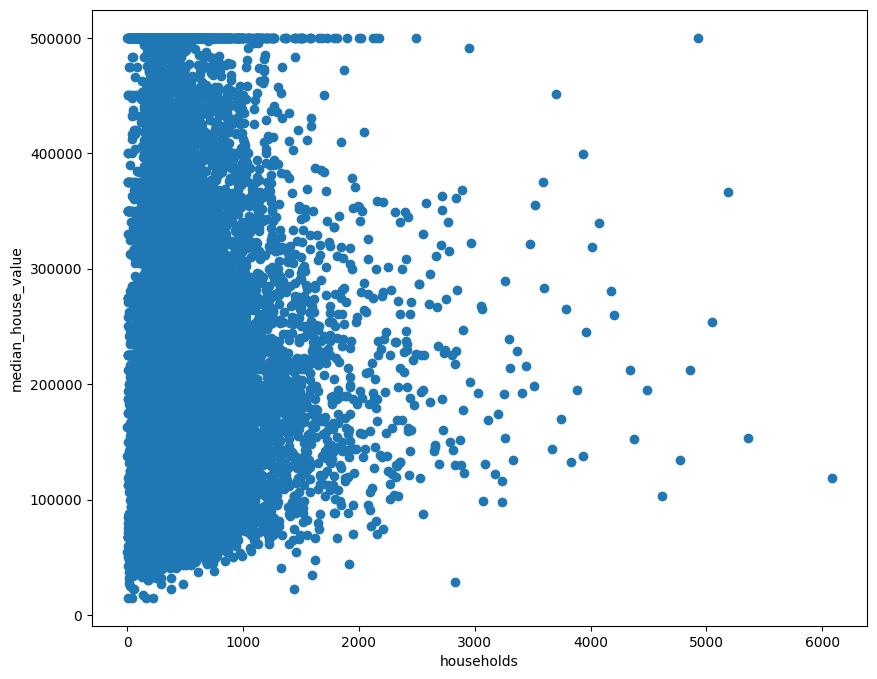

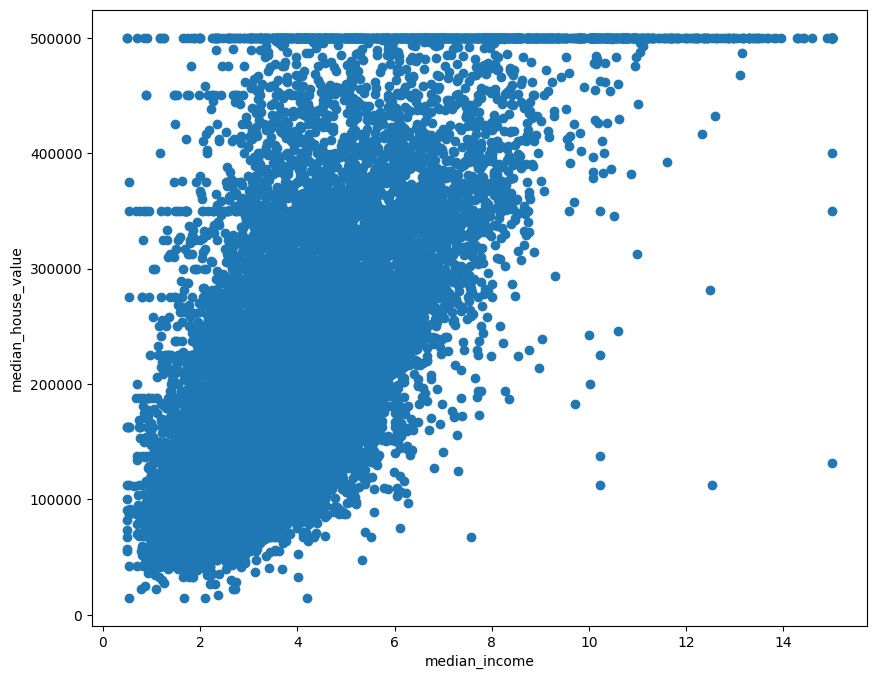

La variable median_house_value es la variable objetivo


In [ ]:
graficas_dispersion(df_descriptivas)

## Variable espaciales vs variable objetivo

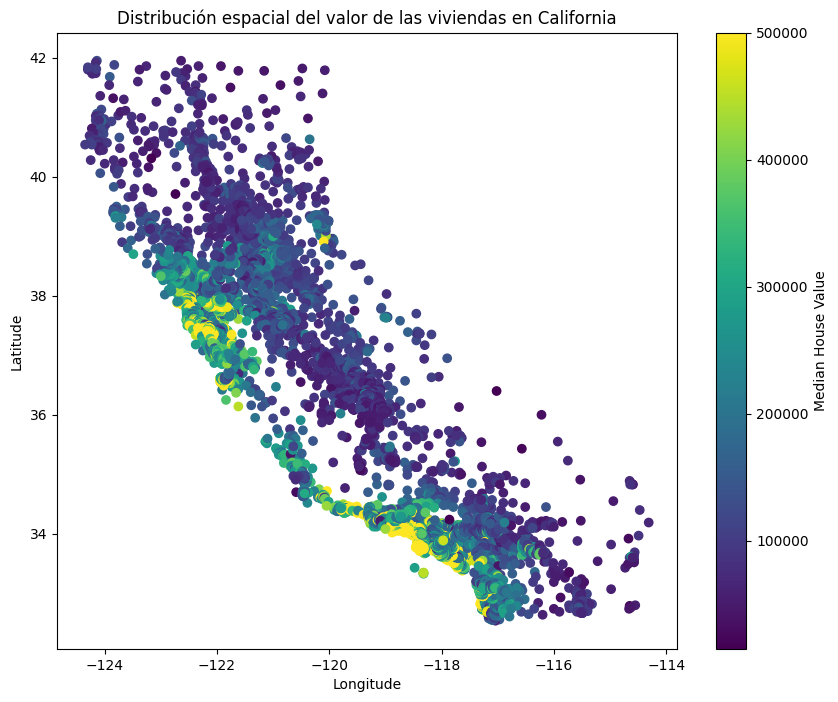

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis"
)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución espacial del valor de las viviendas en California")
plt.show()

##  Preparación de los datos



Después de ver la exploración se enctró

- Datos faltantes en una de las variables

- Muchos datos atípicos en casi todas las variables.

- Temos que las varibales cuantitativa incluida la de repsuesta presentan alta varibilidad, todas tiene un cv>>20%

- El conjunto de datos presenta 207 valores faltantes, todos concentrados en la variable total_bedrooms.

In [ ]:
# veamos los fantaes pero en procentajes
(df.isnull().sum()/len(df))*100

,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,1.002907
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


## Imputación El conjunto de datos presenta 207 valores faltantes  total_bedrooms.

Aprovecharemos la informaciónnde la matriz de correlación donde se evenidencia que esta variable está altamente correlacionadas con otras y además estas otras estan copmpeltas

<Axes: >

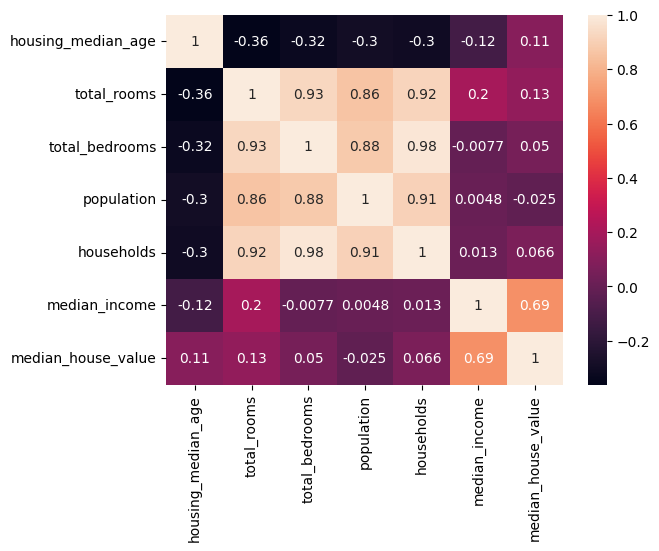

In [ ]:

corr=df_descriptivas.corr()
sns.heatmap(corr, annot=True)

In [ ]:
df_1=df.copy()

In [ ]:
# Dividide los datos apr ael entrenamiento
from sklearn.model_selection import train_test_split
X=df_1.drop('median_house_value',axis=1)
y=df_1['median_house_value']
train_df, test_df, train_labels, test_labels = train_test_split(X, y, test_size=0.3)

In [ ]:
# imputación de la  variable total_bedrooms. 207 valores faltantes
# usamos regresión lineal
from sklearn.linear_model import LinearRegression
#Variavles auxilares
var_imputacion=['total_rooms','households','population']
# registos completos  e incompletos  de total_bedrooms
train_completos=train_df[train_df['total_bedrooms'].notna()]
train_faltantes=train_df[train_df['total_bedrooms'].isna()]

# datos para  imputaipon por regrsion
X_imp=train_completos[var_imputacion]
y_imp=train_completos['total_bedrooms']
#ajsutamos elmodelo para imputar

modelo_imputacion=LinearRegression()
modelo_imputacion.fit(X_imp,y_imp)




LinearRegression()

In [ ]:
train_faltantes.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
19559,-120.98,37.60,36.0,1437.0,NaN,1073.0,320.0,2.1779,INLAND
18261,-122.08,37.37,29.0,1229.0,NaN,707.0,194.0,7.1108,NEAR BAY
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,<1H OCEAN
3328,-122.72,38.88,29.0,2781.0,NaN,890.0,310.0,1.9906,INLAND


In [ ]:
#predceir los valores faltantes ahora
bed_imput_predichos=np.round(modelo_imputacion.predict(train_faltantes[var_imputacion]))
bed_imput_predichos



array([ 329.,  213.,  443.,  915.,  382.,  392., 1439.,  262.,  627.,
        391.,  804.,  298.,  188.,  295.,  434.,  207.,  401.,  419.,
        297.,  115.,  725.,  406., 1302., 1339.,  430.,  140.,  582.,
        638.,  808.,  263.,  542.,  564.,  823.,  504.,  380., 1023.,
        389.,  693.,  228.,  108.,  241.,  280.,  588.,  672.,  560.,
        962.,  545.,  422.,  368.,  605., 1034.,  100.,  631., 1509.,
        617.,  359.,  375.,  567.,  364.,  412.,  784.,  293.,  607.,
        776.,  473.,  246.,  123.,  255.,  819.,  284.,  264., 1400.,
       1049.,  482., 1035.,  485.,  953.,  406.,  164.,  759.,  249.,
        505.,  197.,  428.,  651.,   20.,  720., 1535., 1159.,  108.,
        428.,  658.,  543.,  615.,  749.,  271.,  482.,  165.,  101.,
       1349.,  226.,  291.,  322.,  422.,  204.,  542.,  768.,  639.,
        250., 1589.,  431.,  615.,  621.,  286.,  503.,  283.,  172.,
        471.,  681.,  301.,  427.,  309.,   67.,  293.,  720.,  534.,
        908., 1036.,

In [ ]:
#ahora imputamos las posiones donde hay  datos faltantes

train_df.loc[
    train_df['total_bedrooms'].isna(),
    'total_bedrooms'
] = bed_imput_predichos


In [ ]:
# comprobar los dstos
train_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0


In [ ]:
#ahora imputamos los datos de test
# Ahora imputamos los datos faltantes de test

test_df.loc[
    test_df['total_bedrooms'].isna(),
    'total_bedrooms'
] = np.round(
    modelo_imputacion.predict(
        test_df.loc[test_df['total_bedrooms'].isna(), var_imputacion]
    )
)

In [ ]:
# comprobar
test_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0


##  Trasnformamao la vairable ocean_proximity

In [ ]:
# vemos la varaible ocean_proximity
train_df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,6392
INLAND,4560
NEAR OCEAN,1858
NEAR BAY,1633
ISLAND,5


In [ ]:
# aplicamos onhot_encoding
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

ocean_proximity_encoded = encoder.fit_transform(
    train_df[['ocean_proximity']]
)

ocean_proximity_encoded_df = pd.DataFrame(
    ocean_proximity_encoded,
    columns=encoder.get_feature_names_out(['ocean_proximity']),
    index=train_df.index
)

ocean_proximity_encoded_df.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14119,0.0,0.0,0.0,0.0,1.0
9422,0.0,0.0,0.0,0.0,1.0
20105,0.0,1.0,0.0,0.0,0.0
1655,0.0,1.0,0.0,0.0,0.0
13647,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Eliminamos la variable categórica original
train_df = train_df.drop('ocean_proximity', axis=1)

# Agregamos las variables creadas mediante One-Hot Encoding
train_df = pd.concat(
    [train_df, ocean_proximity_encoded_df],
    axis=1
)

train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14119,-117.09,32.75,30.0,1899.0,546.0,1620.0,493.0,1.6034,0.0,0.0,0.0,0.0,1.0
9422,-122.66,37.93,42.0,1505.0,324.0,553.0,277.0,4.1792,0.0,0.0,0.0,0.0,1.0
20105,-120.30,37.97,17.0,3243.0,619.0,1408.0,566.0,2.4740,0.0,1.0,0.0,0.0,0.0
1655,-121.99,37.92,14.0,1780.0,224.0,764.0,226.0,9.0243,0.0,1.0,0.0,0.0,0.0
13647,-117.31,34.08,40.0,2011.0,495.0,1528.0,469.0,1.9375,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Aplicamos el mismo One-Hot Encoder a TEST
ocean_proximity_encoded_test = encoder.transform(
    test_df[['ocean_proximity']]
)

# Convertimos el resultado en DataFrame
ocean_proximity_encoded_test_df = pd.DataFrame(
    ocean_proximity_encoded_test,
    columns=encoder.get_feature_names_out(['ocean_proximity']),
    index=test_df.index
)

ocean_proximity_encoded_test_df.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3122,0.0,1.0,0.0,0.0,0.0
15491,1.0,0.0,0.0,0.0,0.0
3902,1.0,0.0,0.0,0.0,0.0
9370,0.0,0.0,0.0,1.0,0.0
16929,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Eliminamos la variable categórica original
test_df = test_df.drop('ocean_proximity', axis=1)

# Agregamos las variables creadas con One-Hot Encoding
test_df = pd.concat(
    [test_df, ocean_proximity_encoded_test_df],
    axis=1
)

test_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3122,-117.84,35.35,28.0,1913.0,486.0,858.0,371.0,1.9962,0.0,1.0,0.0,0.0,0.0
15491,-117.18,33.15,7.0,6225.0,1683.0,5410.0,1580.0,2.3200,1.0,0.0,0.0,0.0,0.0
3902,-118.51,34.20,34.0,2871.0,581.0,1350.0,535.0,3.7049,1.0,0.0,0.0,0.0,0.0
9370,-122.52,37.92,24.0,421.0,64.0,163.0,75.0,14.5833,0.0,0.0,0.0,1.0,0.0
16929,-122.32,37.57,33.0,3384.0,819.0,2626.0,793.0,3.2285,0.0,0.0,0.0,0.0,1.0


# Ajustamos el modelo CART

Para este caso ajsutamos un arbol de decisión pero sin bsucar hiperparámetros, soo para ver sus resultados

In [ ]:
#Ajustamos un arbol de decision para regresion inicial
from sklearn.tree import DecisionTreeRegressor as CART
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#creamos el modelo
modelo_CART = CART()
#entrenamos el modelo
modelo_CART.fit(train_df, train_labels)


DecisionTreeRegressor()

In [ ]:
#predecimos
predicciones = modelo_CART.predict(test_df)
predicciones[:10]

array([ 61400., 325000., 222500., 500001., 267700., 311500.,  75900.,
       330500., 291000.,  89500.])

In [ ]:
# calculamos metrica ahora
mae = mean_absolute_error(test_labels, predicciones)
mse = mean_squared_error(test_labels, predicciones)
rmse = np.sqrt(mse)
r2 = r2_score(test_labels, predicciones)
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 43462.02357881137
MSE: 4684476274.0713825
RMSE: 68443.2339539226
R2: 0.6383830827345454


### Interpretación de las métricas del modelo

1. **MAE = 43,106.83:** en promedio, la predicción se aleja del valor real de la vivienda aproximadamente **$43,107**.

2. **MSE = 4,618,199,037.61:** es el promedio de los errores al cuadrado. Su magnitud grande se debe a que está expresado en **dólares²**, por lo que es difícil interpretarlo directamente.

3. **RMSE = 67,957.33:** penaliza más fuertemente los errores grandes. El error típico bajo esta métrica es aproximadamente **$67,957**.

4. **$R^2 = 0.6537$:** el modelo explica aproximadamente **65.37% de la variabilidad** observada en `median_house_value` en el conjunto de **TEST**.

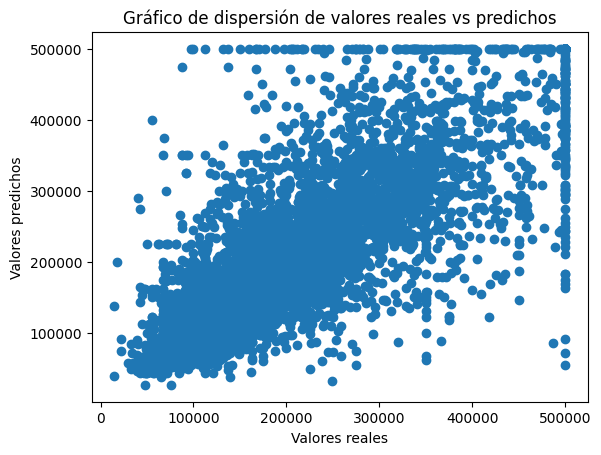

In [ ]:
# hacemos un graido de las valores rpdicho vs los reales
plt.scatter(test_labels, predicciones)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Gráfico de dispersión de valores reales vs predichos")
plt.show()

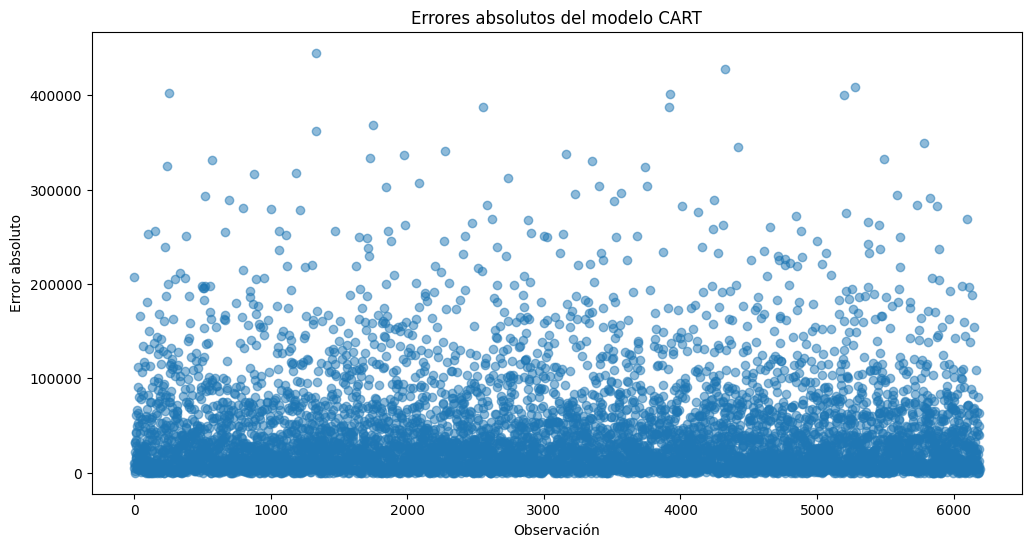

In [ ]:
# ahora hagamos un grafico  de los errores
# error absoluto de cada predicción
# Error absoluto de cada predicción
errores = np.abs(test_labels - predicciones)

# Gráfico de los errores
plt.figure(figsize=(12,6))
plt.scatter(range(len(errores)), errores, alpha=0.5)

plt.xlabel("Observación")
plt.ylabel("Error absoluto")
plt.title("Errores absolutos del modelo CART")
plt.show()


### Errores absolutos

La mayoría de las observaciones presentan **errores relativamente bajos**, aunque existen algunos casos con errores considerablemente altos, superiores a **$300,000**. Esto indica que el modelo funciona razonablemente para gran parte de los datos, pero tiene dificultades en algunas observaciones específicas.

In [ ]:
resultados = pd.DataFrame({
    'Real': test_labels,
    'Prediccion': predicciones,
    'Error_absoluto': np.abs(test_labels - predicciones)
})

resultados.sort_values(
    'Error_absoluto',
    ascending=False
).head(10)

,Real,Prediccion,Error_absoluto
20322,500001.0,55000.0,445001.0
15660,500001.0,72500.0,427501.0
12138,500001.0,91100.0,408901.0
303,97500.0,500001.0,402501.0
6376,486800.0,85600.0,401200.0
15592,100000.0,500001.0,400001.0
4492,112500.0,500001.0,387501.0
5057,87500.0,475000.0,387500.0
13761,131300.0,500000.0,368700.0
19006,137500.0,500001.0,362501.0


### Análisis de los errores extremos del modelo CART

Al analizar los errores absolutos de las predicciones, se observa que la mayoría presentan magnitudes relativamente moderadas. Sin embargo, existen algunas observaciones con errores considerablemente grandes, superiores a $300\,000$ e incluso $400\,000$.

Un aspecto particularmente interesante es que el valor **500001** aparece repetidamente entre las observaciones con los errores más grandes. Por ejemplo:

| Valor real | Predicción | Error absoluto |
|---:|---:|---:|
| 37500 | 500001 | 462501 |
| 500001 | 55000 | 445001 |
| 82500 | 500001 | 417501 |
| 500001 | 100000 | 400001 |

Este comportamiento merece ser estudiado antes de concluir que estos casos corresponden simplemente a valores atípicos (*outliers*).

La repetición exacta del valor **500001** podría indicar la existencia de un límite superior en el registro de la variable `median_house_value`. Es decir, valores superiores a cierto límite podrían haber sido registrados con un mismo valor máximo.

Por ejemplo, conceptualmente podría ocurrir algo como:

| Precio real | Valor registrado |
|---:|---:|
| 300000 | 300000 |
| 420000 | 420000 |
| 490000 | 490000 |
| 520000 | 500001 |
| 600000 | 500001 |

Sin embargo, esta hipótesis debe verificarse antes de realizar cualquier modificación sobre los datos.

Por esta razón, se analizará la frecuencia de los valores de `median_house_value`, particularmente la frecuencia con la que aparece el valor **500001**.

```python
df['median_house_value'].value_counts().head(10)

## Revisamos el sobreajuste

In [ ]:
# Predicciones en TRAIN
pred_train = modelo_CART.predict(train_df)

# Predicciones en TEST
pred_test = modelo_CART.predict(test_df)

# Métricas TRAIN
MAE_train = mean_absolute_error(train_labels, pred_train)
RMSE_train = np.sqrt(mean_squared_error(train_labels, pred_train))
R2_train = r2_score(train_labels, pred_train)

# Métricas TEST
MAE_test = mean_absolute_error(test_labels, pred_test)
RMSE_test = np.sqrt(mean_squared_error(test_labels, pred_test))
R2_test = r2_score(test_labels, pred_test)

print("----- TRAIN -----")
print("MAE:", MAE_train)
print("RMSE:", RMSE_train)
print("R2:", R2_train)

print("\n----- TEST -----")
print("MAE:", MAE_test)
print("RMSE:", RMSE_test)
print("R2:", R2_test)

----- TRAIN -----
MAE: 0.0
RMSE: 0.0
R2: 1.0

----- TEST -----
MAE: 43462.02357881137
RMSE: 68443.2339539226
R2: 0.6383830827345454


### Evidencia de sobreajuste

El modelo CART presenta **sobreajuste**: logra un ajuste perfecto en TRAIN, pero su desempeño disminuye considerablemente en TEST.

| Métrica | TRAIN | TEST |
|---|---:|---:|
| MAE | **0.00** | **44,047.09** |
| RMSE | **0.00** | **68,774.34** |
| $R^2$ | **1.0000** | **0.6485** |

El árbol prácticamente **memoriza los datos de entrenamiento**, debido a su alta complejidad. Sin embargo, no logra generalizar de la misma manera ante datos nuevos.

Por tanto,  es necesario **regularizar el árbol**.

## Creamos un arbol regularizado


En este parate creamos un árbol regularizdo, usamos una busqueda por Grid, para compara varios modelos de árboles.

In [ ]:
from sklearn.tree import DecisionTreeRegressor as CART
from sklearn.model_selection import GridSearchCV

# Modelo base
modelo_CART_grid = CART(random_state=42)

# Grilla de hiperparámetros de regularización
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

# Búsqueda mediante validación cruzada
grid = GridSearchCV(
    estimator=modelo_CART_grid,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# IMPORTANTE: solamente usamos TRAIN
grid.fit(train_df, train_labels)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor RMSE promedio en CV:")
print(-grid.best_score_)

Mejores hiperparámetros:
{'max_depth': 20, 'min_samples_leaf': 20, 'min_samples_split': 2}

Mejor RMSE promedio en CV:
59845.41876552017


In [ ]:
pred_test_reg = grid.best_estimator_.predict(test_df)

MAE_reg = mean_absolute_error(test_labels, pred_test_reg)
RMSE_reg = np.sqrt(mean_squared_error(test_labels, pred_test_reg))
R2_reg = r2_score(test_labels, pred_test_reg)

print("MAE:", MAE_reg)
print("RMSE:", RMSE_reg)
print("R2:", R2_reg)

MAE: 38841.05214231037
RMSE: 57424.49577700415
R2: 0.7454447391813732


In [ ]:
pred_train_reg = grid.best_estimator_.predict(train_df)

MAE_train_reg = mean_absolute_error(train_labels, pred_train_reg)
RMSE_train_reg = np.sqrt(mean_squared_error(train_labels, pred_train_reg))
R2_train_reg = r2_score(train_labels, pred_train_reg)

print("MAE TRAIN:", MAE_train_reg)
print("RMSE TRAIN:", RMSE_train_reg)
print("R2 TRAIN:", R2_train_reg)

print("\nProfundidad:", grid.best_estimator_.get_depth())
print("Número de hojas:", grid.best_estimator_.get_n_leaves())

MAE TRAIN: 33590.54094539618
RMSE TRAIN: 50301.72277456945
R2 TRAIN: 0.8120987259424466

Profundidad: 18
Número de hojas: 549


# Regularización con busqueda Bayesiana



In [ ]:
!pip install scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.8 MB/s eta 0:00:00


In [ ]:
from sklearn.tree import DecisionTreeRegressor as CART
from skopt import BayesSearchCV as BayesSR
from skopt.space import Integer, Real

modelo_CART_bayes = CART(random_state=42)

espacio_busqueda = {
    'max_depth': Integer(5, 35),

    'min_samples_split': Integer(2, 50),

    'min_samples_leaf': Integer(2, 50),

    'ccp_alpha': Real(
        1e-2,
        1e6,
        prior='log-uniform'
    )
}

bayes = BayesSR(
    estimator=modelo_CART_bayes,
    search_spaces=espacio_busqueda,
    n_iter=75,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

bayes.fit(train_df, train_labels)

print("Mejores hiperparámetros:")
print(bayes.best_params_)

print("\nMejor RMSE CV:")
print(-bayes.best_score_)

Mejores hiperparámetros:
OrderedDict({'ccp_alpha': 2731.4136747268653, 'max_depth': 27, 'min_samples_leaf': 19, 'min_samples_split': 43})

Mejor RMSE CV:
59607.609372514984


In [ ]:
pred_test_reg_bayes = bayes.best_estimator_.predict(test_df)

MAE_reg = mean_absolute_error(test_labels, pred_test_reg_bayes)
RMSE_reg = np.sqrt(mean_squared_error(test_labels, pred_test_reg_bayes))
R2_reg = r2_score(test_labels, pred_test_reg_bayes)

print("MAE:", MAE_reg)
print("RMSE:", RMSE_reg)
print("R2:", R2_reg)

MAE: 38824.77235503903
RMSE: 57370.36950928349
R2: 0.7459243823241446


In [ ]:
pred_train_reg_bayes = bayes.best_estimator_.predict(train_df)

MAE_train_reg = mean_absolute_error(train_labels, pred_train_reg_bayes)
RMSE_train_reg = np.sqrt(mean_squared_error(train_labels, pred_train_reg_bayes))
R2_train_reg = r2_score(train_labels, pred_train_reg_bayes)

print("MAE TRAIN:", MAE_train_reg)
print("RMSE TRAIN:", RMSE_train_reg)
print("R2 TRAIN:", R2_train_reg)

print("\nProfundidad:", bayes.best_estimator_.get_depth())
print("Número de hojas:", bayes.best_estimator_.get_n_leaves())

MAE TRAIN: 33634.557572919395
RMSE TRAIN: 50282.572153774076
R2 TRAIN: 0.812241772377463

Profundidad: 18
Número de hojas: 533


## Eliminamos la variable categorica de nuestros datos

Eliminamos la variable categorica y corremos nuestro modelo de nuev, desamos ver si aporte o no??

In [ ]:
# Copiamos lss para no modificar los datos originales
train_sin_ocean = train_df.copy()
test_sin_ocean = test_df.copy()

# Identificar las columnas creadas por ocean_proximity
columnas_ocean = [
    col for col in train_df.columns
    if col.startswith('ocean_proximity_')
]

print(columnas_ocean)

# Eliminarlas
train_sin_ocean = train_sin_ocean.drop(columns=columnas_ocean)
test_sin_ocean = test_sin_ocean.drop(columns=columnas_ocean)

print("TRAIN:", train_sin_ocean.shape)
print("TEST:", test_sin_ocean.shape)

['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
TRAIN: (14448, 8)
TEST: (6192, 8)


In [ ]:
from sklearn.tree import DecisionTreeRegressor as CART

modelo_sin_ocean = CART(
    ccp_alpha=2731.4136747268653,
    max_depth=27,
    min_samples_leaf=19,
    min_samples_split=43
)

modelo_sin_ocean.fit(train_sin_ocean, train_labels)

pred_sin_ocean = modelo_sin_ocean.predict(test_sin_ocean)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

MAE = mean_absolute_error(test_labels, pred_sin_ocean)
RMSE = np.sqrt(mean_squared_error(test_labels, pred_sin_ocean))
R2 = r2_score(test_labels, pred_sin_ocean)

print("MAE:", MAE)
print("RMSE:", RMSE)
print("R2:", R2)

MAE: 39008.33459035205
RMSE: 58432.726886050354
R2: 0.7364275557838207


## Evaluación del aporte de `ocean_proximity`

Como análisis adicional, se retiraron las variables generadas mediante One-Hot Encoding para `ocean_proximity` y se evaluó nuevamente el árbol.

Al eliminar esta información, el desempeño en TEST disminuyó ligeramente. Por esta razón, se decidió conservar `ocean_proximity` dentro del conjunto de variables predictoras.

#

## `Conclusión  finales`

En este ejercicio se ajustó un árbol de decisión para predecir el valor de las viviendas. El primer modelo presentó un fuerte sobreajuste, ya que obtuvo un $R^2=1$ en entrenamiento, pero su desempeño bajó bastante al evaluarlo con los datos de prueba.

Por esta razón, se regularizó el árbol y se buscaron mejores hiperparámetros usando Grid Search y búsqueda bayesiana. Con esto se logró reducir el sobreajuste y obtener un modelo que generaliza mejor, alcanzando aproximadamente un $R^2=0.81$ en entrenamiento y $R^2=0.75$ en prueba.

También se probó eliminar `ocean_proximity`, pero los resultados empeoraron ligeramente, por lo que se decidió conservarla. En general, el ejercicio permitió ver que un árbol más complejo no necesariamente es mejor y que controlar su complejidad es fundamental para obtener mejores resultados sobre datos nuevos.